In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
orders_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_orders_dataset.csv")
order_items_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_order_items_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Jyots\AppData\Local\Temp\ipykernel_19108\628114856.py:1: SyntaxWarning: invalid escape sequence '\P'
  orders_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_orders_dataset.csv")
C:\Users\Jyots\AppData\Local\Temp\ipykernel_19108\628114856.py:2: SyntaxWarning: invalid escape sequence '\P'
  order_items_df = pd.read_csv("D:\Projects\Cart2Insights\Data\Cleaned\clist_order_items_dataset.csv")


In [4]:
merged_df = pd.merge(orders_df,order_items_df,on="order_id",how="inner")

In [5]:
merged_df['order_purchase_timestamp'] = pd.to_datetime(merged_df['order_purchase_timestamp'])

merged_df.set_index('order_purchase_timestamp', inplace=True)

In [6]:
# Downsample to monthly frequency and calculate total revenue
monthly_revenue = merged_df['price'].resample('ME').sum().reset_index()

# Rename columns for clarity
monthly_revenue.columns = ['Month', 'Total_Revenue']
print(monthly_revenue)

        Month  Total_Revenue
0  2016-09-30         267.36
1  2016-10-31       49507.66
2  2016-11-30           0.00
3  2016-12-31          10.90
4  2017-01-31      120312.87
5  2017-02-28      247303.02
6  2017-03-31      374344.30
7  2017-04-30      359927.23
8  2017-05-31      506071.14
9  2017-06-30      433038.60
10 2017-07-31      498031.48
11 2017-08-31      573971.68
12 2017-09-30      624401.69
13 2017-10-31      664219.43
14 2017-11-30     1010271.37
15 2017-12-31      743914.17
16 2018-01-31      950030.36
17 2018-02-28      844178.71
18 2018-03-31      983213.44
19 2018-04-30      996647.75
20 2018-05-31      996517.68
21 2018-06-30      865124.31
22 2018-07-31      895507.22
23 2018-08-31      854686.33
24 2018-09-30         145.00


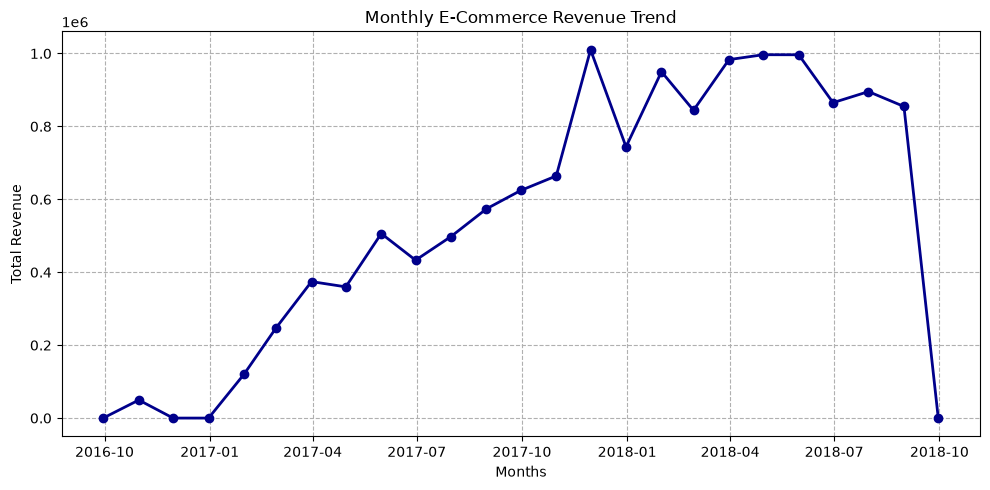

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['Month'], monthly_revenue['Total_Revenue'], marker='o', color='darkblue', linewidth=2)

plt.title('Monthly E-Commerce Revenue Trend')
plt.xlabel('Months')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()